# Klasifikasi DemogPairs Menggunakan Fitur ViT (Umur) & SVM

In [1]:
import numpy as np
import utilsv2 as u
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from tqdm import tqdm

joblib.parallel_backend('threading')

## Load Dataset

In [2]:
data = u.load_demogpairs()
pd.DataFrame(data)

,db_code,image_path,full_path,label,label_idx
0,CWF,able_wanamakok/002.jpg,dataset/demogpairs/images/able_wanamakok/002.jpg,Asian_Females,5
1,CWF,able_wanamakok/004.jpg,dataset/demogpairs/images/able_wanamakok/004.jpg,Asian_Females,5
2,CWF,able_wanamakok/007.jpg,dataset/demogpairs/images/able_wanamakok/007.jpg,Asian_Females,5
3,CWF,able_wanamakok/008.jpg,dataset/demogpairs/images/able_wanamakok/008.jpg,Asian_Females,5
4,CWF,able_wanamakok/012.jpg,dataset/demogpairs/images/able_wanamakok/012.jpg,Asian_Females,5
...,...,...,...,...,...
10795,CWF,zachary_quinto/177.jpg,dataset/demogpairs/images/zachary_quinto/177.jpg,White_Males,3
10796,CWF,zachary_quinto/214.jpg,dataset/demogpairs/images/zachary_quinto/214.jpg,White_Males,3
10797,CWF,zachary_quinto/217.jpg,dataset/demogpairs/images/zachary_quinto/217.jpg,White_Males,3
10798,CWF,zachary_quinto/218.jpg,dataset/demogpairs/images/zachary_quinto/218.jpg,White_Males,3


## Load Fitur

In [3]:
features = joblib.load('features/demogpairs_vit-age.pkl')
print('Jumlah fitur per gambar:', np.array(features[list(features.keys())[0]]).shape[0])

Jumlah fitur per gambar: 768


## Split Data

In [4]:
X = np.array([features[d['image_path']] for d in data])
y = np.array([d['label_idx'] for d in data])
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print((len(X_train), len(X_test)))

(8640, 2160)


## Kombinasi Parameter

In [5]:
from sklearn.decomposition import PCA

grid_params = [
    {
        'scaler': [None, MinMaxScaler()],  # EN: scaling option / ID: opsi scaling
        'pca': [None, PCA(n_components=0.5), PCA(n_components=0.75)],  # EN: with and without PCA / ID: dengan dan tanpa PCA
        
        'classifier': [SVC()],  # EN: SVM model / ID: model SVM
        
        'classifier__C': [0.01, 0.1, 1, 10],  # EN: regularization / ID: regularisasi
        'classifier__kernel': ['rbf', 'poly', 'linear'],  # EN: kernel types / ID: jenis kernel
        
        'classifier__gamma': ['scale', 'auto'],  # EN: gamma / ID: gamma
        'classifier__degree': [2, 3],  # EN: degree / ID: derajat
        
        'classifier__tol': [1e-3],  # EN: tolerance / ID: toleransi
        'classifier__probability': [True],  # EN: probability / ID: probabilitas
    },
]

pipeline = Pipeline(steps=[
    ('scaler', None),  # EN: optional scaler / ID: scaler opsional
    ('pca', None),     # EN: optional PCA / ID: PCA opsional
    ('classifier', None)  # EN: classifier / ID: classifier
])

skv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy', 
    'f1': 'f1_macro', 
    'precision': 'precision_macro', 
    'recall': 'recall_macro',
    'roc_auc_ovr': 'roc_auc_ovr'
}

grid_models = {}
for params in grid_params:
    key = str(params['classifier'][0]).split('(')[0]
    grid_models[key] = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        cv=skv, refit='accuracy',
        scoring=scoring, n_jobs=int(joblib.cpu_count() * 0.6),
        verbose=1, error_score='raise',
        return_train_score=True
    )
    print(f'{key}: {len(ParameterGrid(params))} kombinasi')

SVC: 288 kombinasi


## Klasifikasi

Mengevaluasi model: SVC
Fitting 5 folds for each of 288 candidates, totalling 1440 fits


{'classifier': 'SVC', 'classifier__C': 10, 'classifier__degree': 2, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf', 'classifier__probability': True, 'classifier__tol': 0.001, 'pca': None, 'scaler': None}


Accuracy  : 0.8763888888888889
Precision : 0.8766833495444749
Recall    : 0.8763888888888888
F1 Score  : 0.8764627782355291
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       360
           1       0.89      0.86      0.87       360
           2       0.87      0.87      0.87       360
           3       0.93      0.91      0.92       360
           4       0.82      0.84      0.83       360
           5       0.87      0.87      0.87       360

    accuracy                           0.88      2160
   macro avg       0.88      0.88      0.88      2160
weighted avg       0.88      0.88      0.88      2160



Class,Accuracy,Precision,Recall,F1-Score
Black_Males,0.9657407407407408,0.8885869565217391,0.9083333333333333,0.8983516483516484
White_Females,0.9587962962962963,0.8882521489971347,0.8611111111111112,0.8744710860366713
Asian_Males,0.9560185185185185,0.8650137741046832,0.8722222222222222,0.8686030428769018
White_Males,0.9731481481481481,0.9265536723163842,0.9111111111111111,0.9187675070028011
Black_Females,0.9430555555555555,0.8246575342465754,0.8361111111111111,0.8303448275862069
Asian_Females,0.9560185185185185,0.8670360110803325,0.8694444444444445,0.8682385575589459


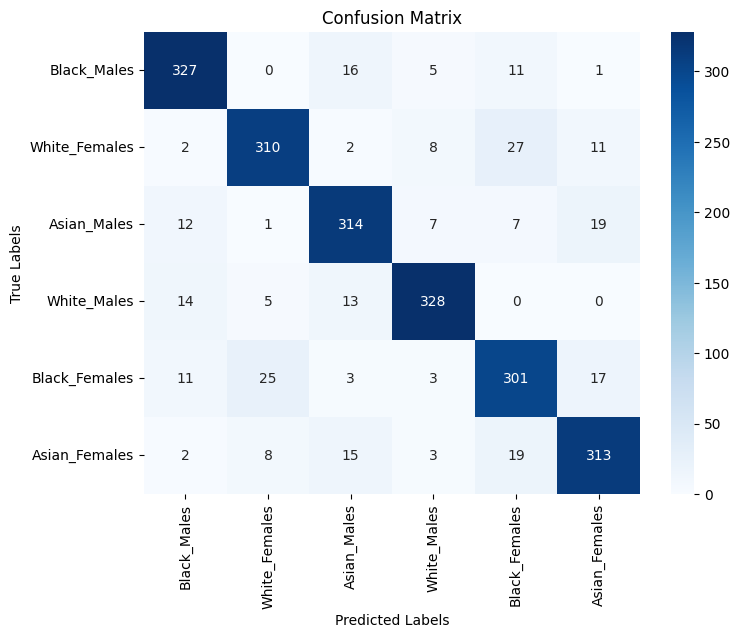

model_name,model_file_path,best_parameters,test_accuracy,test_f1,test_precision,test_recall,parameter_combinations
SVC,models/clf_demogpairs_svm_vit-age_SVC.pkl,"{'classifier': 'SVC', 'classifier__C': 10, 'classifier__degree': 2, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf', 'classifier__probability': True, 'classifier__tol': 0.001, 'pca': None, 'scaler': None}",0.8763888888888889,0.8764627782355291,0.8766833495444749,0.8763888888888888,288


In [6]:
evaluation_results, fold_results = u.evaluate_models(
    grid_models,
    X_train, y_train,
    X_test, y_test,
    model_prefix='models/clf_demogpairs_svm_vit-age_',
    results_path='results/demogpairs_svm_vit-age_'
)

sorted_results = pd.DataFrame(evaluation_results).sort_values(by='test_accuracy', ascending=False).to_dict('records')
u.html_br()
_dtable = u.display_table(sorted_results)

In [7]:
model, training_time = u.load_object('models/clf_demogpairs_svm_vit-age_SVC.pkl')
u.h(5, 'Waktu Pelatihan (Jobs)')
u.seconds_to_time(round(training_time))

{'input_seconds': 15309.0,
 'days': 0,
 'hours': 4,
 'minutes': 15,
 'seconds': 9.0,
 'text': '0 hari 4 jam 15 menit 9.0 detik'}

In [8]:
u.h(5, 'Waktu Pelatihan')
times = [fr['Train Time Mean'] * 5 for fr in fold_results]
u.seconds_to_time(round(np.sum(times) + model.refit_time_))

{'input_seconds': 127224.0,
 'days': 1,
 'hours': 11,
 'minutes': 20,
 'seconds': 24.0,
 'text': '1 hari 11 jam 20 menit 24.0 detik'}

In [9]:
def remove_keys(data, keys_to_remove, inplace=False):
    # EN: if not inplace, create a copy / ID: jika tidak inplace, buat salinan
    if not inplace:
        data = data.copy()
    
    # EN: loop through keys and remove safely / ID: loop key dan hapus dengan aman
    for key in keys_to_remove:
        data.pop(key, None)  # EN: avoid error if key not found / ID: aman jika key tidak ada
    
    return data

def dict_to_sentence(d):
    # EN: convert key-value pairs into readable parts / ID: ubah key-value jadi bagian kalimat
    parts = [f"{k}={v}" for k, v in d.items()]
    
    # EN: join all parts into one sentence / ID: gabungkan jadi satu kalimat
    sentence = ", ".join(parts)
    
    return sentence

fold_displays = []
for r in [remove_keys(r, ['No', 'F1 Score Mean', 'Precision Mean', 'Recall Mean', 'Train Time Mean']) for r in fold_results]:
    r['Params'] = dict_to_sentence(remove_keys(r['Params'], ['classifier'])).replace('classifier__', '')
    r['Mean'] = r['Accuracy Mean']
    del r['Accuracy Mean']
    fold_displays.append(r)
fold_displays = [{'No': idx + 1, **r} for idx, r in enumerate(sorted(fold_displays, key=lambda x: x['Mean'], reverse=True))]
_dtable = u.display_table(fold_displays, n_items=[3, 3, 3, 3], column_widths=['5%', '65%', '5%', '5%', '5%', '5%', '5%', '5%'])

No,Params,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean
1,"C=10, degree=3, gamma=scale, kernel=rbf, probability=True, tol=0.001, pca=None, scaler=None",0.8744,0.8582,0.8646,0.8669,0.875,0.8678
2,"C=10, degree=2, gamma=scale, kernel=rbf, probability=True, tol=0.001, pca=None, scaler=None",0.8744,0.8582,0.8646,0.8669,0.875,0.8678
3,"C=10, degree=2, gamma=scale, kernel=rbf, probability=True, tol=0.001, pca=None, scaler=MinMaxScaler",0.8744,0.8565,0.8576,0.8715,0.8762,0.8672
...,...,...,...,...,...,...,...
96,"C=0.01, degree=3, gamma=auto, kernel=linear, probability=True, tol=0.001, pca=PCA, scaler=None",0.805,0.8009,0.7951,0.8032,0.8084,0.8025
97,"C=0.01, degree=2, gamma=scale, kernel=linear, probability=True, tol=0.001, pca=PCA, scaler=None",0.805,0.8009,0.7951,0.8032,0.8084,0.8025
98,"C=0.01, degree=3, gamma=scale, kernel=linear, probability=True, tol=0.001, pca=PCA, scaler=None",0.805,0.8009,0.7951,0.8032,0.8084,0.8025
...,...,...,...,...,...,...,...
191,"C=0.01, degree=2, gamma=auto, kernel=linear, probability=True, tol=0.001, pca=PCA, scaler=MinMaxScaler",0.6505,0.6354,0.625,0.6325,0.6539,0.6395
192,"C=0.1, degree=3, gamma=scale, kernel=poly, probability=True, tol=0.001, pca=PCA, scaler=MinMaxScaler",0.6314,0.6499,0.6319,0.6383,0.6453,0.6394
